<a href="https://colab.research.google.com/github/Umukundwa004/assignment_logistc_andNeuralNetwork/blob/main/Assignment1_VESTINE_umukundwa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**formative 1: classical ML and neural networks**

**name :vestine umukundwa**

**Introduction**

This notebook presents an analysis of the Parkinson's disease dataset, aiming to classify individuals with Parkinson's  disease using various machine learning models. The dataset, sourced from the UCI  Machine Learning Repository , contains structured numerical features  that are well-suited for both classical machine learning and neural network approaches .

**data source and citation**

*   **Dataset:** Parkinson's Disease (voice measurements)
*   **Source:** UCI Machine Learning Repository
*   **Link:** https://archive.ics.uci.edu/dataset/174/parkinsons
*   **Citation:** Little, M. (2007). Parkinson's [Dataset]. UCI Machine Learning Repository. doi.org/10.24432/C59C74

In [423]:
#Importing python Libraries we need for tasks like data manipulation,building models ,evaluation and also visualization.
import numpy as np
import os as os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, ConfusionMatrixDisplay,classification_report)

In [424]:
# pip install ucimlrepo

In [425]:
# extracting the data from aploaded ziped file (parkinsons.zip)
import zipfile

zip_path = '/content/parkinsons.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/parkinsons_data')

print("Extraction is  complete")

Extraction is  complete


In [461]:
# Load the data file
#the extracted parkinsons data file is loaded into a pandas DataFrame named df
zip_path = '/content/parkinsons_data/parkinsons.data'
df = pd.read_csv(zip_path)


print(f"Dataset Shape: {df.shape}")
df.info() #for the summary of columns data types
df

Dataset Shape: (195, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               1

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [462]:
# checking if we have any missing values in all columns in the DataFrame
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [463]:
# checking if we have any duplicted rows in the dataframe
df.duplicated().sum()

np.int64(0)

In [464]:
#for displaying columns names
print("Columns in the current DataFrame (df):")
print(df.columns.tolist())

Columns in the current DataFrame (df):
['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [465]:
# dividing the dataset into features X and the target variable which is y
# x contail all other column except "name" and "status"
X=df.drop(['name', 'status'], axis=1) # droping 'status' as our target variable and droping 'name' which is not predictive feature
y=df['status'] # y target contains only the 'status' column

print(f"Features in new dataframe shape: {X.shape}")
print("\nFirst 5 rows of features (X):")
display(X.head())
print("\nFirst 5 values of target (y):")
display(y.head())



Features in new dataframe shape: (195, 22)

First 5 rows of features (X):


,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335



First 5 values of target (y):


,status
0,1
1,1
2,1
3,1
4,1


In [466]:
#checking again if we ghave any missing value
print(X.isnull().sum())

MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


**splitting the data**

In [467]:
# Splitting the data for train and Test Splites
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Scaling because the features have different numerical ranges,purposely for putting features on a similar scale.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling complete.")

Data splitting and scaling complete.


# Logistic Regression

**logistic regression: experiment 1 (C=1.0)**

This experiment initializes and trains a Logistic Regression model with a regularization parameter C set to 1.0.

In [468]:
#this is for initializing and training a Logistic Regression model with the regularization c=1.0
model1 = LogisticRegression(C=1.0)
model1.fit(X_train_scaled, y_train.values.ravel())

pred1 = model1.predict(X_test_scaled)

In [469]:
# for valuating Metrics for Logistic Regression where C=1.0
accuracy = accuracy_score(y_test, pred1)
precision = precision_score(y_test, pred1)
recall = recall_score(y_test, pred1)
f1 = f1_score(y_test, pred1)

print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1 Score:  {f1}")

Accuracy:  0.8974358974358975
Precision: 0.8888888888888888
Recall:    1.0
F1 Score:  0.9411764705882353


For this first experiment, the model shows   performance with high accuracy, excellent recall, and a strong F1-score.

**logistic regression: experiment 2 (C=0.1)**

In this second experiment, the Logistic Regression model is trained with a stronger regularization, setting the C parameter to 0.1.

In [470]:
#in this experiment we also trained the Logistic Regression model again, but with a stronger regularization (C=0.1),because the smaller the c the higher the regularization
model2 = LogisticRegression(C=0.1)
model2.fit(X_train_scaled, y_train.values.ravel())

pred2 = model2.predict(X_test_scaled)

In [471]:
# this  calculates and displays the accuracy, precision, recall, and F1-score for the second Logistic Regression modelwhere C=0.1
accuracy = accuracy_score(y_test, pred2)
precision = precision_score(y_test, pred2)
recall = recall_score(y_test, pred2)
f1 = f1_score(y_test, pred2)

print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1 Score:  {f1}")

Accuracy:  0.8974358974358975
Precision: 0.8888888888888888
Recall:    1.0
F1 Score:  0.9411764705882353


**logistic regression: experiment 3 (C=10)**

For the third Logistic Regression experiment, the regularization parameter C is increased to 10.

In [472]:
# this my last logisic regression experiment, where i have C is increased to 10, meaning i have applied less regularization.
model3 = LogisticRegression(C=10)
model3.fit(X_train_scaled, y_train.values.ravel())

pred3 = model3.predict(X_test_scaled)

In [473]:
# this  calculates and displays the accuracy, precision, recall, and F1-score for the last LogisticRegression  experiment i did model where C=10
accuracy = accuracy_score(y_test, pred3)
precision = precision_score(y_test, pred3)
recall = recall_score(y_test, pred3)
f1 = f1_score(y_test, pred3)

print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1 Score:  {f1}")

Accuracy:  0.8974358974358975
Precision: 0.9117647058823529
Recall:    0.96875
F1 Score:  0.9393939393939394


**logistic regression experiments conclusion**

By comparing the results i obtained from Experiments 1, 2, and 3, we can observe the impact of changing  regularization strength on the model's ability to generalize. A higher C (less regularization) generally allows  the model to fit the training data more aggressively, potentially leading to slightly different performance metrics on  the test set.

**logistic regression confusion matrix**

This section provides and displays a confusion matrix for the Logistic Regression model, utilizing predictions  from pred1 , derived from the first experiment.

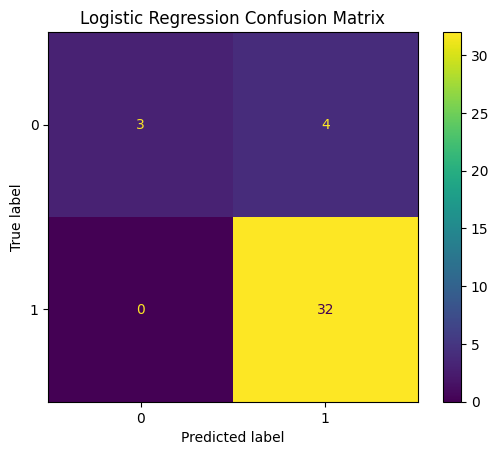

In [474]:
#this is for generates and displays a confusion matrix for the Logistic Regression model using predictions from , pred1 first experiment
confusionmatrix_logisticregression = confusion_matrix(y_test, pred1)
# plot implementation for confusion matrix
ConfusionMatrixDisplay(confusionmatrix_logisticregression).plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

This means that we have:
*   **True Positives (TP): 32** - This is the number of people who are actually sick and the model correctly predicted them as sick.
*   **True Negatives (TN): 3** - This is the number of people who are not sick and the model correctly predicted them as not sick.
*   **False Negatives (FN): 0** - This is the number of people who are actually sick, but the model incorrectly predicted them as not sick. Having zero false negatives is a very good outcome in this context.
*   **False Positives (FP): 4** - This is the number of people who are not sick, but the model incorrectly predicted them as sick.

The Logistic Regression model demonstrated robust performance, particularly in terms of recall, but it did generate a few false positives. This indicates that while the model successfully identified all Parkinson’s patients (high recall), it occasionally misclassified healthy individuals as having the disease.

**random forest classifier**

**random foreest rlassifier: experiment 1 (n_estimators=100, max_depth=5)**



In [475]:
#experiment we initialize and train a Random Forest Classifier
rf_model1 = RandomForestClassifier(n_estimators=100, max_depth=5,random_state=42)#number of tree in forest=100 ,limit maximum depth of each tree=5 ,reproducibility=42
rf_model1.fit(X_train_scaled, y_train.values.ravel())

rf_pred1 = rf_model1.predict(X_test_scaled)
# calculating and displaying evaluation metrics (accuracy, precision, recall, F1-score)
accuracy = accuracy_score(y_test, rf_pred1)
precision = precision_score(y_test, rf_pred1)
recall = recall_score(y_test, rf_pred1)
f1 = f1_score(y_test, rf_pred1)

print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1 Score:  {f1}")

Accuracy:  0.9487179487179487
Precision: 0.9411764705882353
Recall:    1.0
F1 Score:  0.9696969696969697


The random forest model in this experiment shows strong performance, by achieving high levels of both accuracy and  precision. this suggests its effectiveness in correctly classifying instances and minimizing  false  positive predictions.

**random corest classifier: experiment 2 (n_estimators=200, max_depth=10)**

This second experiment continues the investigation of the Random Forest Classifier, this time with modified hyperparameters. The number of trees (n_estimators) is increased to 200, and the maximum depth (max_depth) of each tree is set to 10.

In [476]:
# second experiment we initialize and train a Random Forest Classifier  again
rf_model2 = RandomForestClassifier(n_estimators=200, max_depth=10,random_state=42) #number of tree in forest=200 ,limit maximum depth of each tree=10,reproducibility=42
rf_model2.fit(X_train_scaled, y_train.values.ravel())

rf_pred2 = rf_model1.predict(X_test_scaled)
# calculating and displaying evaluation metrics (accuracy, precision, recall, F1-score)
accuracy = accuracy_score(y_test, rf_pred2)
precision = precision_score(y_test, rf_pred2)
recall = recall_score(y_test, rf_pred2)
f1 = f1_score(y_test, rf_pred2)

print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1 Score:  {f1}")

Accuracy:  0.9487179487179487
Precision: 0.9411764705882353
Recall:    1.0
F1 Score:  0.9696969696969697


**random forest classifier: experiment 3 ( n_estimators=300,  max_depth=None)**

In the final Random Forest experiment, the number of trees (n_estimators) is further increased to 300, and the max_depth parameter is set to None

In [477]:
# last experiment we also initialize and train a Random Forest Classifier
#number of tree in forest=300 ,limit maximum depth of each tree=None,reproducibility=42
rf_model3 = RandomForestClassifier(n_estimators=300, max_depth=None,random_state=42)

rf_model3.fit(X_train_scaled, y_train.values.ravel())

rf_pred3 = rf_model1.predict(X_test_scaled)
# calculating and displaying evaluation metrics (accuracy, precision, recall, F1-score)
accuracy = accuracy_score(y_test, rf_pred3)
precision = precision_score(y_test, rf_pred3)
recall = recall_score(y_test, rf_pred3)
f1 = f1_score(y_test, rf_pred3)

print(f"Accuracy:  {accuracy}")
print(f"Precision: {precision}")
print(f"Recall:    {recall}")
print(f"F1 Score:  {f1}")

Accuracy:  0.9487179487179487
Precision: 0.9411764705882353
Recall:    1.0
F1 Score:  0.9696969696969697


 extra explanayions:max_depth=None means trees expand fully, aiming to capture all possible patterns, but increasing the risk of overfitting individual trees

**random forest confusion matrix**

This confusion matrix illlustrates the performance of the random forest model, specifically using predictions from rf_pred3, from last experiment.

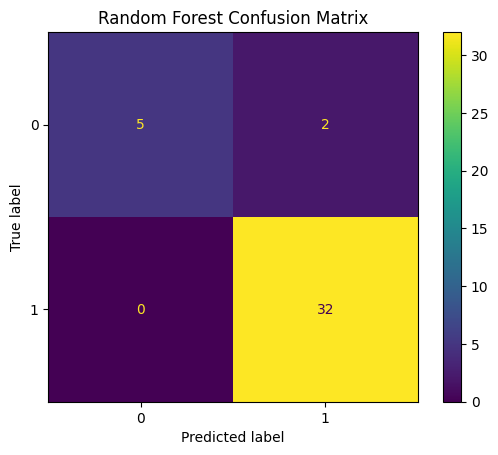

In [478]:
#confusion matrix for the random Forest model (using predictions from rf_pred3)last experiment
confusionmatrix_rf = confusion_matrix(y_test, rf_pred3)
#plot implementation for random forest model confusion matrix
ConfusionMatrixDisplay(confusionmatrix_rf).plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

this means that we have:                               
True Positives (TP):32this the true actual number of people who are sick                            
True Negatives (TN):5 this number of peole who are not sick                                
False Negatives (FN):0 this is the number of peaple who are not sick but model predict that they are sick but actually they don`t and it is good thing that we have zero                                
False Positives (FP):2 this is number of people who are sick but model predict that they are healthy

The Random Forest model performed slightly better overall, especially in reducing misclassifications. As the number of trees and depth increased, performance became more stable and accurate.

**conclusion: logistic regression vs. random forest**

After completing  rondom forest model  and logistic regression model, Random Forest performed way better than Logistic Regression because it captured  more complex patterns  in the Parkinson’s dataset.

# Neural Network from Scratch

## Initialize Neural Network Parameters

This section gives the architecture of neural network.

**data preparation**

In [479]:
#Data preparation for neural network
#convert training features and test features to NumPy array by using scaled data
 #regression because neural networks works best with numpy arrays

x_train = np.array(X_train_scaled)
x_test= np.array(X_test_scaled)
# for automatic converting number all rows into one column(corrct dimension one vector column)
y_train = np.array(y_train).reshape(-1, 1)
y_test = np.array(y_test).reshape(-1, 1)

In [480]:
# for displaying  first 5 rows of the X_train NumPy array.
X_train[:5]

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
5,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,0.456,...,0.03243,0.06985,0.01222,21.378,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
135,110.453,127.611,105.554,0.00494,0.00004,0.00244,0.00315,0.00731,0.04128,0.379,...,0.03316,0.06688,0.02529,17.707,0.653427,0.706687,-5.333619,0.322044,2.631793,0.228319
122,138.190,203.522,83.340,0.00704,0.00005,0.00406,0.00398,0.01218,0.04479,0.441,...,0.03220,0.07761,0.01968,18.305,0.538016,0.741480,-5.418787,0.160267,2.090438,0.229892
167,260.105,264.919,237.303,0.00339,0.00001,0.00205,0.00186,0.00616,0.02030,0.197,...,0.01367,0.03557,0.00910,21.083,0.440988,0.628058,-7.517934,0.160414,1.881767,0.075587
85,180.978,200.125,155.495,0.00406,0.00002,0.00220,0.00244,0.00659,0.03852,0.331,...,0.02877,0.06321,0.02782,16.176,0.583574,0.727747,-5.657899,0.315903,3.098256,0.200423


**initializing Parameters**

In [481]:
#for getting random number ensuring that the random initializing of weights is reproducible.
np.random.seed(42)
# defining network structure
input_size = X_train.shape[1]
hidden1 = 16  #first hidden layer has 16 neurons
hidden2 = 8  #second hidden layer has 8 neurons
output_size = 1 #output layer with one neuron  for Binary classification (0 or 1)

# weight and bias initialization
W1 = np.random.randn(input_size, hidden1) * 0.01 # first layer weights
b1 = np.zeros((1, hidden1)) # first layer bias

W2 = np.random.randn(hidden1, hidden2) * 0.01 # second layer weights
b2 = np.zeros((1, hidden2))#second layer bias

W3 = np.random.randn(hidden2, output_size) * 0.01 # output  layer weights
b3 = np.zeros((1, output_size))#Output bias

## Activation Functions

 **rectified linear unit (ReLU)**

The relu function implements the Rectified Linear Unit activation. this function returns the input value directly if it is positive, and returns zero otherwise.
The derivative_of  relu function calculates the derivative of the ReLU function.

In [482]:
#the relu function implements the Rectified Linear unit activation function
def relu(Z):
    return np.maximum(0, Z)
# the derivative_ofrelu function  is for calculateing the derivative of the ReLU function.
def derivative_ofrelu(Z):
    return (Z > 0).astype(float)

**Sigmoid activation**

In [483]:
#implementing sigmoid activation function with formula (1 / (1 + exp(-Z)))
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))
#The derivative_ofsigmoid function computes the derivative of the sigmoid function
def derivative_ofsigmoid(A):
    return A * (1 - A)

**forward propagation**

The 'forward_propagation function' defines the process by which input data is passed through the neural  network  to give an output.

In [484]:
#defining a forward propagation function
def forward_propagation(X):

    global Z1, A1, Z2, A2, Z3, A3
#result of the linear transformation (Z1,Z2,Z3) is passed through an activation function(ReLU for hidden layers, Sigmoid for the output layer)
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = relu(Z2)

    Z3 = np.dot(A2, W3) + b3
    A3 = sigmoid(Z3)

    return A3    # A3 final output represents the network's prediction

**Binary Cross-Entropy Loss**

The compute_loss function quantifies the discrepancy between the neural network's predicted probabilities (y_pred) and the actual true labels (y_true) using the binary cross-entropy loss function.

In [485]:
# compute_loss function calculates the binary cross entropy loss
def compute_loss(y_true, y_pred):  #it gives the difference between the predicted probabilities (`y_pred`) and the true labels (`y_true`)

    m = y_true.shape[0]

    loss = -1/m * np.sum(
        y_true * np.log(y_pred + 1e-8) +     # we add "1e-8" to prevent logarithm of zero which will result into undefined value
        (1 - y_true) * np.log(1 - y_pred + 1e-8)
    )

    return loss

**backward propagation** the 'backward_propagation' function is central to the training of the neural network.

In [486]:
# the backward_propagation function calculates the gradients of the loss function with respect to the weights and biases of each layer and then updates these parameters to reduce the loss.
def backward_propagation(X, y, learning_rate):

    global W1, b1, W2, b2, W3, b3

    m = X.shape[0]

    dZ3 = A3 - y  # calculate Output Layer Error
    #calculate gradients for output Layer loss
    dW3 = (1/m) * np.dot(A2.T, dZ3)
    db3 = (1/m) * np.sum(dZ3, axis=0, keepdims=True)
      #backpropagate Error to hidden layer 2
    dA2 = np.dot(dZ3, W3.T)
    dZ2 = dA2 * derivative_ofrelu(Z2)
    #calculates gradients for hidden layer 2
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)

    #backpropagate error to hidden layer 1
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * derivative_ofrelu(Z1)
    #calculates gradients for hidden layer 1
    dW1 = (1/m) * np.dot(X.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)


    #apdates weight and bias
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

**Neural Network Training Loop**

This section defines the iterative training process for the neural network. The training loop  progresses over a specified number  of 'epochs', during which  the following steps are executed:

1. step 1: **Forward Propagation:** for predicting network predictions for the current training data (X_train).
2. step2 : **Loss Computation:** The 'compute_loss' function quantifies the error between these  predictions and the actual true labels  (y_train).
3. step 3: **Backward Propagation and Parameter Update:**  calculates the gradients of the  loss with respect to all weights and biases, and updating  these parameters
4. step 4: **Accuracy Calculation:** The continuous predictions are converted into binary class labels (0 or 1) by applying a 0.5 threshold.
5. step 5: **Performance Monitoring:** The computed  loss and accuracy for each epoch are stored in respective lists.

In [487]:
#neural network training lLoop
learning_rate = 0.01
epochs = 1000

losses = []
accuracies = []

for epoch in range(epochs):


    #the forward_propagation function calculates output (predictions) for the current training data
    predictions = forward_propagation(X_train)

    #the compute_loss function calculates the error between the predictions and the true labels (y_train).
    loss = compute_loss(y_train, predictions)

    #The backward_propagation function calculates the gradients of the loss with respect to all weight and bias, and then updates these parameters using gradient descent with the specified learning_rate.
    backward_propagation(X_train, y_train, learning_rate)

    # The predictions are then converted into binary classes (0 or 1) by comparing them to a threshold (0.5), and the training accuracy is calculated.
    predicted_classes = (predictions > 0.5).astype(int)

    accuracy = np.mean(predicted_classes == y_train)

    losses.append(loss)
    accuracies.append(accuracy)

    #the loss and accuracy for each epoch are recorded, and progress is printed every 100 epochs to monitor the training process
    if epoch % 100 == 0:
        print(f'Epoch {epoch}')
        print(f'Loss: {loss:.4f}')
        print(f'Accuracy: {accuracy:.4f}')

Epoch 0
Loss: 0.6936
Accuracy: 0.2628
Epoch 100
Loss: 0.6487
Accuracy: 0.7372
Epoch 200
Loss: 0.6206
Accuracy: 0.7372
Epoch 300
Loss: 0.5978
Accuracy: 0.7372
Epoch 400
Loss: 0.5944
Accuracy: 0.7372
Epoch 500
Loss: 0.5917
Accuracy: 0.7372
Epoch 600
Loss: 0.5891
Accuracy: 0.7372
Epoch 700
Loss: 0.5867
Accuracy: 0.7372
Epoch 800
Loss: 0.5844
Accuracy: 0.7372
Epoch 900
Loss: 0.5823
Accuracy: 0.7372


## Learning Curve Visualization

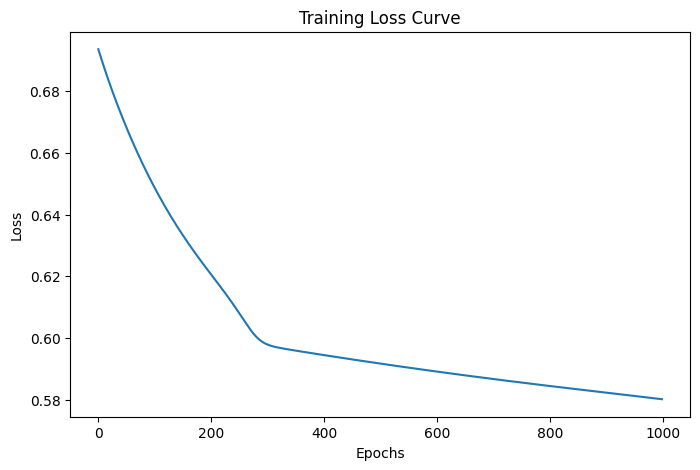

In [488]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

### Training Loss Curve

This plot illustrates the progression of the loss function over the training epochs for the neural network. A consistent decrease in the loss signifies that the model is effectively learning from the training data, progressively minimizing the discrepancy between its predictions and the actual target values.

## Training Accuracy Curve

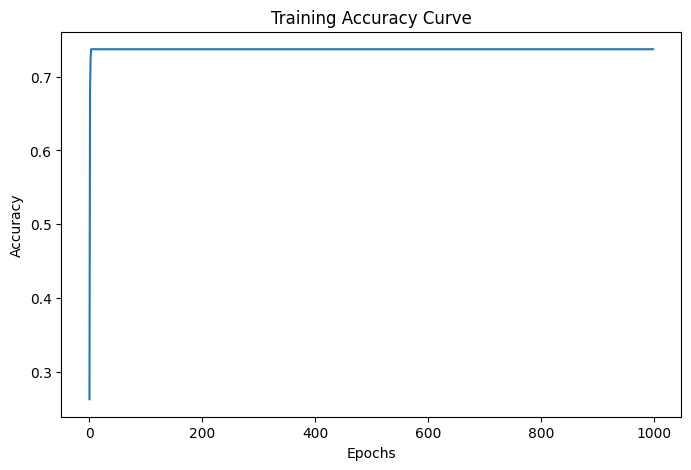

In [489]:
plt.figure(figsize=(8,5))
plt.plot(accuracies)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Curve')
plt.show()

**Training Accuracy Curve**
this pplot shows an increase in accuracy over epochs, which indicates that the model is getting better at correctly classifying the training data over time. As the model trained, its ability to correctly classify the training data improved, showing that the network is successfully identifying the patterns in the dataset

**neural network evaluation by finding the accuracy, precision, recall, and F1 Score**

In [490]:
#neural network evaluation on test set of data
predictions = forward_propagation(X_test) # forward_propagation function is used to get predictions from the trained network on the test features

nn_classes = (predictions > 0.5).astype(int)# predictions are converted to binary classes using a 0.5 threshold
#calculate and display (accuracy, precision, recall, and F1 Score) using the y_test as true labels and the nn_classes predictions
print('Accuracy:', accuracy_score(y_test, nn_classes))
print('Precision:', precision_score(y_test, nn_classes))
print('Recall:', recall_score(y_test, nn_classes))
print('F1 Score:', f1_score(y_test, nn_classes))

Accuracy: 0.8205128205128205
Precision: 0.8205128205128205
Recall: 1.0
F1 Score: 0.9014084507042254


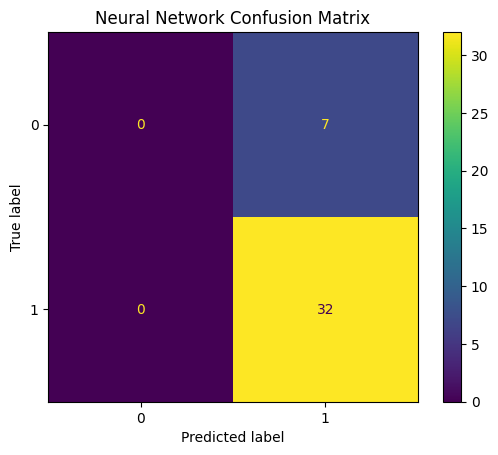

In [491]:
#confusion matrix for the neural network model (using predictions from nn_classes)last experiment
confusionmatrix_nn = confusion_matrix(y_test, nn_classes)

#plot for neural network model confusion matrix
ConfusionMatrixDisplay(confusionmatrix_nn).plot()
plt.title('Neural Network Confusion Matrix')
plt.show()

This means that we have:
*   **True Positives (TP): 32** - This is the number of people who are actually sick and the model correctly predicted them as sick.
*   **True Negatives (TN): 0** - This is the number of people who are not sick and the model correctly predicted them as not sick.
*   **False Negatives (FN): 0** - This is the number of people who are actually sick, but the model incorrectly predicted them as not sick. Having zero false negatives is a very good outcome in this context.
*   **False Positives (FP): 7** - This is the number of people who are not sick, but the model incorrectly predicted them as sick.

The number of false positives is relatively small compared to the true positives, which means the model performs well in identifying sick patients. However, the model still incorrectly classifies some healthy people as sick.

**Neural Network: Experiment 1 (Learning Rate = 0.001, Epochs = 1000)**

This initial experiment for the neural network sets the 'learning_rate' to 0.001 and the number of 'epochs' to 1000. The objective is to observe the model's learning process under these training parameters.

In [492]:
#neural network training experiment 1 with (Learning Rate = 0.001, Epochs = 1000)
learning_rate = 0.001
epochs = 1000

losses = []
accuracies = []

for epoch in range(epochs):

    predictions = forward_propagation(X_train)

    loss = compute_loss(y_train, predictions)

    backward_propagation(X_train, y_train, learning_rate)

    predicted_classes = (predictions > 0.5).astype(int)

    accuracy = np.mean(predicted_classes == y_train)

    losses.append(loss)
    accuracies.append(accuracy)

    if epoch % 100 == 0:

        print(f"experiment one results")
        print(f'Epoch {epoch}')
        print(f'Loss: {loss:.4f}')
        print(f'Accuracy: {accuracy:.4f}')

experiment one results
Epoch 0
Loss: 0.5801
Accuracy: 0.7372
experiment one results
Epoch 100
Loss: 0.5799
Accuracy: 0.7372
experiment one results
Epoch 200
Loss: 0.5798
Accuracy: 0.7372
experiment one results
Epoch 300
Loss: 0.5796
Accuracy: 0.7372
experiment one results
Epoch 400
Loss: 0.5795
Accuracy: 0.7372
experiment one results
Epoch 500
Loss: 0.5793
Accuracy: 0.7372
experiment one results
Epoch 600
Loss: 0.5792
Accuracy: 0.7372
experiment one results
Epoch 700
Loss: 0.5790
Accuracy: 0.7372
experiment one results
Epoch 800
Loss: 0.5789
Accuracy: 0.7372
experiment one results
Epoch 900
Loss: 0.5788
Accuracy: 0.7372


In Experiment 1, the loss decreased very slowly while the accuracy remained constant at 73.72%. suggests that the chosen learning rate might be too low or the number of epochs is not enough.

**Neural Network: Experiment 2 (Learning Rate = 0.001, Epochs = 1500)**

Experiment 2 changed the training duration by increasing the number of 'epochs' to 1500 while maintaining the 'learning_rate' at 0.001.

In [493]:
#neural network training experiment 2  with (Learning Rate = 0.001, Epochs = 1500)
learning_rate = 0.001
epochs = 1500

losses = []
accuracies = []

for epoch in range(epochs):

    predictions = forward_propagation(X_train)

    loss = compute_loss(y_train, predictions)

    backward_propagation(X_train, y_train, learning_rate)

    predicted_classes = (predictions > 0.5).astype(int)

    accuracy = np.mean(predicted_classes == y_train)

    losses.append(loss)
    accuracies.append(accuracy)

    if epoch % 100 == 0:
        print(f'Epoch {epoch}')
        print(f'Loss: {loss:.4f}')
        print(f'Accuracy: {accuracy:.4f}')

Epoch 0
Loss: 0.5787
Accuracy: 0.7372
Epoch 100
Loss: 0.5785
Accuracy: 0.7372
Epoch 200
Loss: 0.5784
Accuracy: 0.7372
Epoch 300
Loss: 0.5783
Accuracy: 0.7372
Epoch 400
Loss: 0.5782
Accuracy: 0.7372
Epoch 500
Loss: 0.5781
Accuracy: 0.7372
Epoch 600
Loss: 0.5780
Accuracy: 0.7372
Epoch 700
Loss: 0.5779
Accuracy: 0.7372
Epoch 800
Loss: 0.5778
Accuracy: 0.7372
Epoch 900
Loss: 0.5777
Accuracy: 0.7372
Epoch 1000
Loss: 0.5777
Accuracy: 0.7372
Epoch 1100
Loss: 0.5776
Accuracy: 0.7372
Epoch 1200
Loss: 0.5775
Accuracy: 0.7372
Epoch 1300
Loss: 0.5774
Accuracy: 0.7372
Epoch 1400
Loss: 0.5773
Accuracy: 0.7372


In Experiment 2, i have increased the number of epochs slightly reduced the loss further, but the accuracy still remained unchanged at 73.72%.

**Neural Network: Experiment 3 (Learning Rate = 0.05, Epochs = 800)**

For Experiment 3, the 'learning_rate' is significantly increased to 0.05, and the number of 'epochs' is set to 800. This change is for modifying  the impact of learning rate on the neural network training and overall performance.

In [494]:
#neural network training experiment 2  with (Learning Rate = 0.001, Epochs = 1500)
learning_rate = 0.05
epochs = 800

losses = []
accuracies = []

for epoch in range(epochs):

    predictions = forward_propagation(X_train)

    loss = compute_loss(y_train, predictions)

    backward_propagation(X_train, y_train, learning_rate)

    predicted_classes = (predictions > 0.5).astype(int)

    accuracy = np.mean(predicted_classes == y_train)

    losses.append(loss)
    accuracies.append(accuracy)

    if epoch % 100 == 0:
        print(f'Epoch {epoch}')
        print(f'Loss: {loss:.4f}')
        print(f'Accuracy: {accuracy:.4f}')

Epoch 0
Loss: 0.5773
Accuracy: 0.7372
Epoch 100
Loss: 0.5671
Accuracy: 0.7372
Epoch 200
Loss: 0.5557
Accuracy: 0.7372
Epoch 300
Loss: 0.5449
Accuracy: 0.7372
Epoch 400
Loss: 0.5237
Accuracy: 0.8205
Epoch 500
Loss: 0.5245
Accuracy: 0.7885
Epoch 600
Loss: 0.5079
Accuracy: 0.7756
Epoch 700
Loss: 0.5002
Accuracy: 0.7756


In Experiment 3, increasing the learning rate to 0.05 this experiment allowed the model to learn faster. The loss decreased more significantly, and the accuracy improved to about 78.21%.



In [495]:
#all models evaluation metrics
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Neural Network'
    ],
    'Accuracy': [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, rf_pred1),
        accuracy_score(y_test, nn_classes)
    ],
    'Precision': [
        precision_score(y_test, pred1),
        precision_score(y_test, rf_pred1),
        precision_score(y_test, nn_classes)
    ],
    'Recall': [
        recall_score(y_test, pred1),
        recall_score(y_test, rf_pred1),
        recall_score(y_test, nn_classes)
    ],
    'F1 Score': [
        f1_score(y_test, pred1),
        f1_score(y_test, rf_pred1),
        f1_score(y_test, nn_classes)
    ]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression  0.897436   0.888889     1.0  0.941176
1        Random Forest  0.948718   0.941176     1.0  0.969697
2       Neural Network  0.820513   0.820513     1.0  0.901408


## Conclusion

The Parkinson’s disease dataset worked well with classical machine learning models because it contains structured numerical features.

*   **Logistic Regression** provided a strong baseline, showing partial linear separability of the classes.
*   **Random Forest** achieved better performance by capturing nonlinear relationships and reducing overfitting through ensemble learning.
*   A **Neural Network** built from scratch also learned meaningful patterns, as shown by decreasing loss and improving accuracy during training, confirming correct implementation of backpropagation and gradient descent. However, the neural network required more complex implementation than classical models.

In healthcare applications, recall is particularly important because missing Parkinson’s cases may delay diagnosis and treatment.

**comparison of the models**

**strengths and weaknesses of each model**

**1. Logistic Regression:**
*  Strengths : Simple, interpretable, and efficient. It performs well when classes can be separated linearly (GeeksforGeeks, Advantages and Disadvantages of Logistic Regression).
*   Weaknesses: it can not handle complex datasets. Its performance can be limited by feature  interactions and non-linear patterns (GeeksforGeeks, Advantages and Disadvantages of Logistic Regression).

**2. random forest:**
*  Strengths :this method that provides high accuracy, handles nonlinear features, and is less prone to overfitting than single  decision trees. and it can also handle a large number of features ( GeeksforGeeks , What are the Advantages and Disadvantages of Random Forest ? ).
*   Weaknesses : Can be less interpretable than simpler models. Training can be computationally intensive for very large datasets or many trees ( GeeksforGeeks , What are the Advantages  and  Disadvantages of Random Forest ?).

**3. neural network:**
*   Strengths : Capable of learning highly complex, nonlinear relationship featrures and it can learn hidden , complex  patterns within the data not obvious at first glance. With proper architecture and training, neural networks can achieve high good p erformance on various tasks ( GeeksforGeeks , Introduction  To Neural Networks ).
*   Weaknesses : Requires significant computational resources and careful tuning of hyperparameters ( e.g., learning rate ,  number of epochs, network architecture ). Training can be time consuming, and debugging can be more challenging due to its hidden  logic nature. Overfitting can be a common  issue if not properly managed ( GeeksforGeeks , Introduction To  Neural Networks ).

 **possible reasons for differences in models  Performance**

*   **random forest outperforming logistic regression:** the dataset contains onlinear relationships between the features and the target variable. Logistic Regression, being a linear model truggles to capture all  relationships, leading to lower p erformance compared to Random Forest, which did well by capturing most of linear and nonlinear relationships

*   **neural network's performance :** This model has performed  slightly worse than the Random Forest and there could be due to several factors:
    *   **hyperparameter tuning :** the learning rate we have used and number of epochs for the neural network might not be optimal.
    *   **network architecture :** The simple architecture i have used  might not be enough due data complexity and it has failed to capture  all relevant patterns.
    *   **initialization:** the random weight initialization  can caouse  training stability and convergence.
    *   **Data Size:** aonther resoason is that our small dataset is not enough for deep neural networks .not having enough data to learn can cause overfitting, whereas ensemble methods like  Random Forest can be more resilient.

**references**

inclass activities notebook,
https://alueducation.instructure.com/courses/2791/files/508257/download?download_frd=1

google colab notebook ,class activity
https://colab.research.google.com/drive/1iDzREIqaPIwA_xUDeYmFbvLp1XTkVx_R#scrollTo=76U82c_wnOI_

Perusall course materials (week 2 neural networks)
https://app.perusall.com/courses/introduction-to-machine-learning-235915774/_/assignments#:~:text=Week2_Intro_to_Neural_Networks_Supplementary_Resource

scikit-learn logistic regression documentation
https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

scikit-learn random Forest classifier
https://scikit-learn.org/stable/modules/ensemble.html#random-forests


Perusall neural networks and deep learning
https://app.perusall.com/courses/introduction-to-machine-learning-235915774/neural-networks-and-deep-learning-596106813?filter=mine

geeksforgeeks,()Advantages and Disadvantages of Logistic Regression,https://www.geeksforgeeks.org/data-science/advantages-and-disadvantages-of-logistic-regression/

geeksforgeeks()What are the Advantages and Disadvantages of Random Forest?,https://www.geeksforgeeks.org/machine-learning/what-are-the-advantages-and-disadvantages-of-random-forest/


geeksforgeeks(),introduction To Neural Networks,https://www.geeksforgeeks.org/deep-learning/neural-networks-a-beginners-guide/
